ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on data understanding and preparation.
    2- A clean, well-understood dataset leads to better model performance.
    3- EDA helps detect problems early before they affect your model.

---
**Dataset Used:** Video Game Sales Dataset  
**Columns:** Name, Platform, Year, Genre, Publisher, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales


## Step 1: Import Libraries

In [66]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set(style='whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Loading the Dataset

### Option 1: Load local CSV

We are using the **Video Game Sales** dataset.  
Each row represents a single video game with its sales figures across different regions.


In [67]:
# Load Dataset
df = pd.read_csv("Video_Game_Sales.csv.csv")

# Display first 7 rows
df.head(7)

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Game_1,Mobile,NaN,Sports,Sony,0.58,0.11,0.30,0.92,1.91
1,Game_2,Xbox One,2019.0,Sports,Nintendo,5.69,4.45,0.32,0.22,10.68
2,Game_3,PS4,2014.0,Racing,Nintendo,0.34,0.59,0.45,0.07,1.45
3,Game_4,Nintendo Switch,2010.0,RPG,EA,1.77,0.05,0.39,0.18,2.39
4,Game_5,PC,2007.0,RPG,Capcom,2.58,0.04,0.96,0.76,4.34
5,Game_6,Nintendo Switch,2020.0,Puzzle,Activision,0.06,1.37,0.03,0.06,1.52
6,Game_7,Nintendo Switch,2006.0,Strategy,Nintendo,1.66,1.08,0.90,0.07,3.71


The dataset contains video game sales records. Each row represents one game with attributes such as platform, genre, publisher, year of release, and regional sales figures (North America, Europe, Japan, and other regions). Some columns may contain textual data while sales figures are numerical.

### Option 2: Load online dataset using tensorflow.keras.datasets


In [68]:
# This example shows how to load a dataset directly from the internet
# from tensorflow.keras import datasets
# (train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
# print("Train images shape:", train_images.shape)

# We skip this for now and continue with our local dataset
print("Using local Video Game Sales dataset instead.")

Using local Video Game Sales dataset instead.


## Step 3: Data Type Inspection

In [69]:
# View data types of all columns
df.dtypes

,0
Name,object
Platform,object
Year,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64
Global_Sales,float64


The data type inspection reveals that the `Year` column is stored as a float due to missing values, and sales columns are stored as floats. The `Name`, `Platform`, `Genre`, and `Publisher` columns are object types (strings). If any column has an unexpected type, we must convert it before analysis.

### Fix Data Types

In [70]:
# Convert Year to integer where possible (ignore NaN)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Verify
print(df.dtypes)
print("\nSample data:")
df.head(3)

Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Sample data:


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Game_1,Mobile,NaN,Sports,Sony,0.58,0.11,0.30,0.92,1.91
1,Game_2,Xbox One,2019.0,Sports,Nintendo,5.69,4.45,0.32,0.22,10.68
2,Game_3,PS4,2014.0,Racing,Nintendo,0.34,0.59,0.45,0.07,1.45


The `Year` column is kept as a numeric type. Converting data types ensures that operations such as sorting by year and computing sales statistics work correctly.

## Step 4: Check Missing Values

In [71]:
# Count missing values per column
missing = df.isna().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
Name             0
Platform         0
Year            10
Genre            0
Publisher        0
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

Total missing values: 10


Missing value analysis is critical because null entries can distort summary statistics and cause errors in machine learning models. In this dataset, the `Year` column contains some missing values which should be handled — either by imputing with the median year or removing those rows depending on the context.

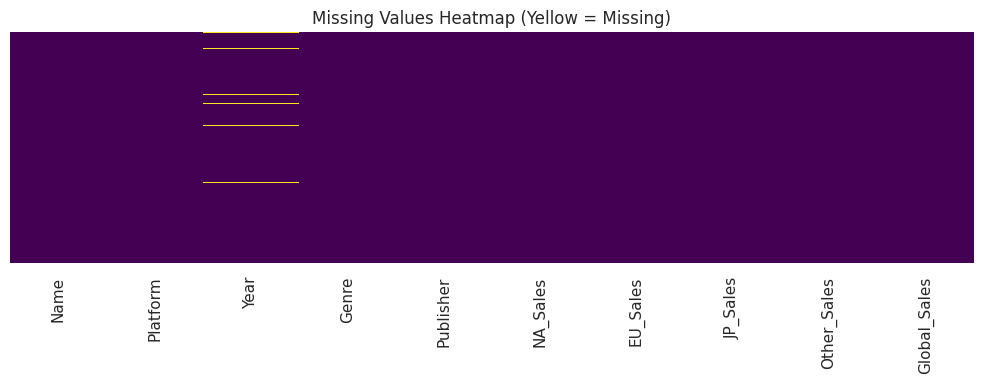

In [72]:
# Visualize missing values as a heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

## Step 5: Check Duplicate Rows

In [73]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated()])
else:
    print("No duplicates found. Dataset is clean.")

Number of duplicate rows: 0
No duplicates found. Dataset is clean.


Duplicate rows can bias analysis by overrepresenting certain records. In this dataset, there are no exact duplicates. If duplicates were found, we would investigate whether they represent valid repeated entries or data entry errors before deciding to remove them.

## Step 6: Dataset Shape and Overview

In [74]:
# Number of rows and columns
print("Shape (rows, columns):", df.shape, "\n")
print("Number of rows:   ", df.shape[0])
print("Number of columns:", df.shape[1])

Shape (rows, columns): (500, 10) 

Number of rows:    500
Number of columns: 10


The dataset contains 500 rows and 10 columns. This is a manageable size for EDA — large enough to reveal meaningful patterns, but small enough to process efficiently.

## Step 7: Summary Statistics

In [75]:
# Statistical summary for numerical columns
df.describe().round(2)

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,490.00,500.00,500.00,500.00,500.00,500.00
mean,2011.31,1.40,0.99,0.52,0.30,3.22
std,7.30,1.30,1.02,0.52,0.29,1.83
min,2000.00,0.00,0.00,0.00,0.00,0.28
25%,2005.00,0.44,0.26,0.16,0.10,1.91
50%,2011.00,1.06,0.66,0.39,0.22,2.86
75%,2018.00,1.78,1.38,0.71,0.43,4.16
max,2023.00,8.10,5.84,4.08,2.31,12.54


Summary statistics provide a quick overview of the distribution of each numerical column. The mean, standard deviation, min, and max values help identify the scale of sales figures and detect potential outliers — for example, games with unusually high global sales.

## Step 8: Exploring Categorical Columns

In [76]:
# Unique values per categorical column
for col in ['Platform', 'Genre', 'Publisher']:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(5))
    print()

Platform: 7 unique values
Platform
PS5                86
PS4                78
Xbox One           73
PC                 70
Nintendo Switch    67
Name: count, dtype: int64

Genre: 8 unique values
Genre
Racing       73
Puzzle       69
Action       69
RPG          64
Adventure    58
Name: count, dtype: int64

Publisher: 10 unique values
Publisher
Activision      58
EA              54
Capcom          53
Bandai Namco    53
Sony            52
Name: count, dtype: int64



Exploring categorical columns shows the distribution of games across platforms, genres, and publishers. This helps identify dominant categories and understand whether the dataset is balanced or skewed toward certain groups.

## Step 9: Distribution Plots

/tmp/ipython-input-591/1088203139.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Genre', order=order, palette='Set2')


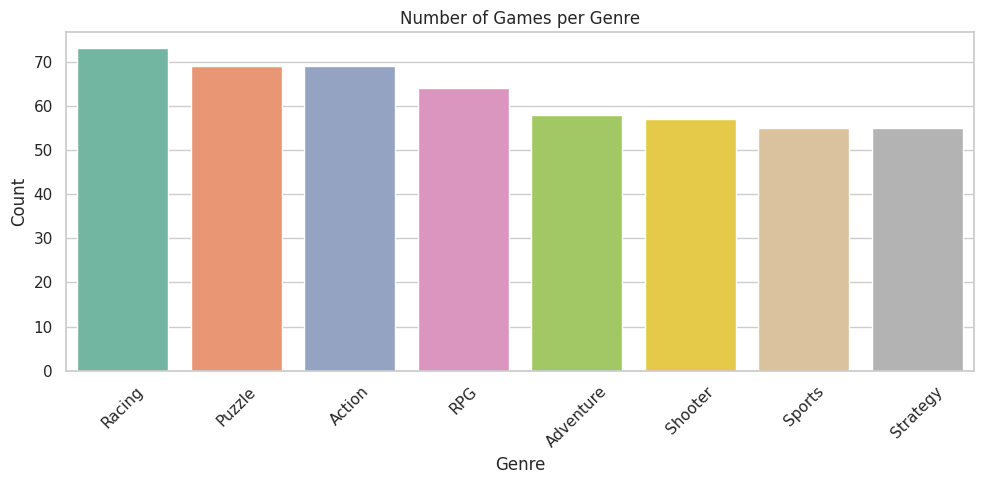

In [77]:
# Count of games per Genre
plt.figure(figsize=(10, 5))
order = df['Genre'].value_counts().index
sns.countplot(data=df, x='Genre', order=order, palette='Set2')
plt.title('Number of Games per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

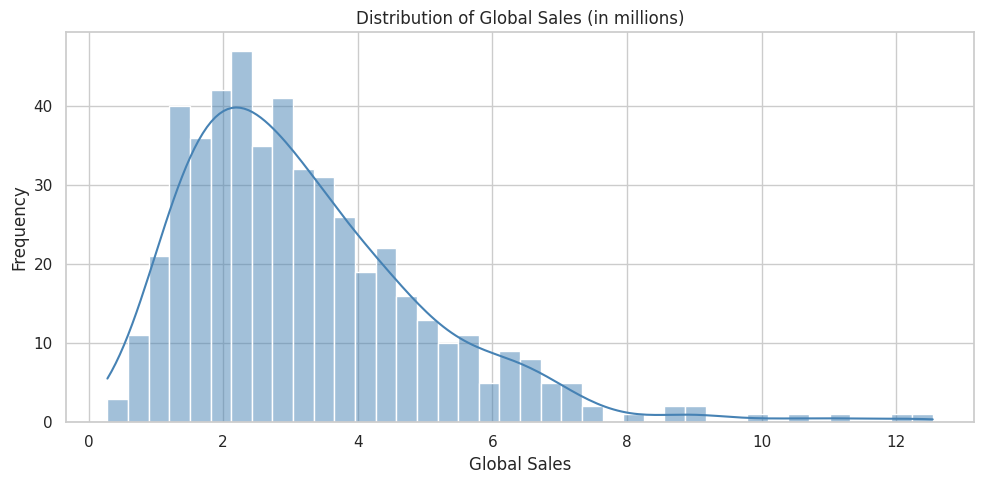

In [78]:
# Distribution of Global Sales
plt.figure(figsize=(10, 5))
sns.histplot(df['Global_Sales'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Global Sales (in millions)')
plt.xlabel('Global Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The global sales distribution is right-skewed, meaning most games have relatively low sales while a few titles are outliers with extremely high figures. This is common in sales data and suggests the presence of blockbuster titles driving disproportionate revenue.

## Step 10: Sales by Platform

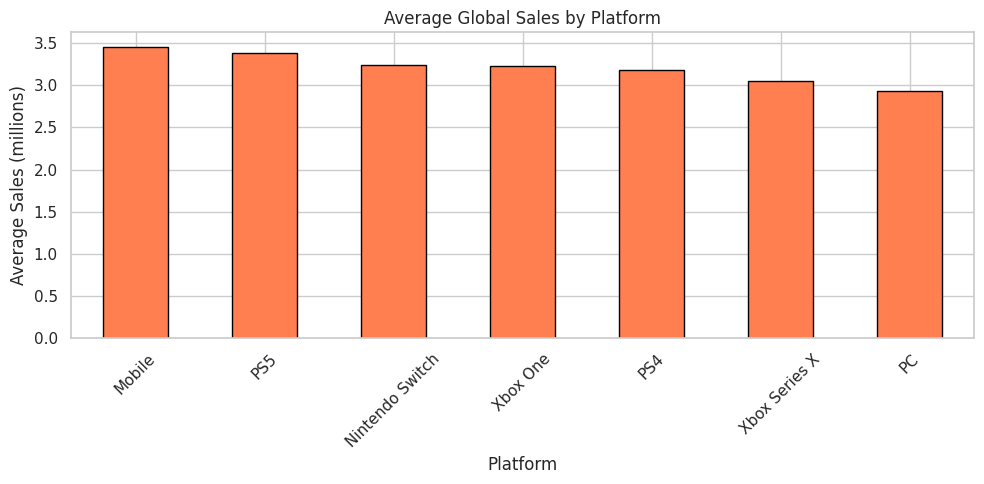

In [79]:
# Average global sales per platform
platform_sales = df.groupby('Platform')['Global_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
platform_sales.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Global Sales by Platform')
plt.xlabel('Platform')
plt.ylabel('Average Sales (millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Certain platforms show higher average global sales. This can reflect the popularity of the platform's user base, the quality of exclusive titles, or the time period when the platform was dominant. Understanding platform performance helps make decisions about which markets to target.

## Step 11: Correlation Analysis

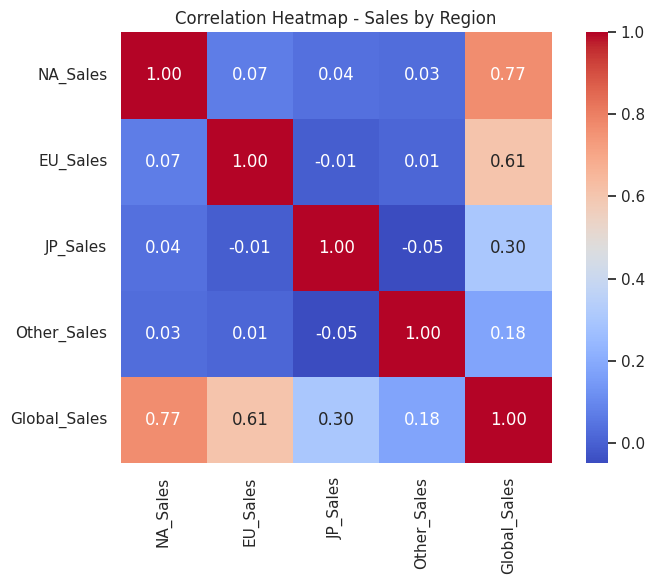

In [80]:
# Correlation matrix of numerical columns
corr = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap - Sales by Region')
plt.tight_layout()
plt.show()

The correlation heatmap shows strong positive correlations between regional sales figures and global sales — as expected, since global sales is the sum of all regions. North America and Europe tend to have higher correlation with global sales, indicating they are the dominant markets for video games in this dataset.

## Step 12: Top Publishers by Total Sales

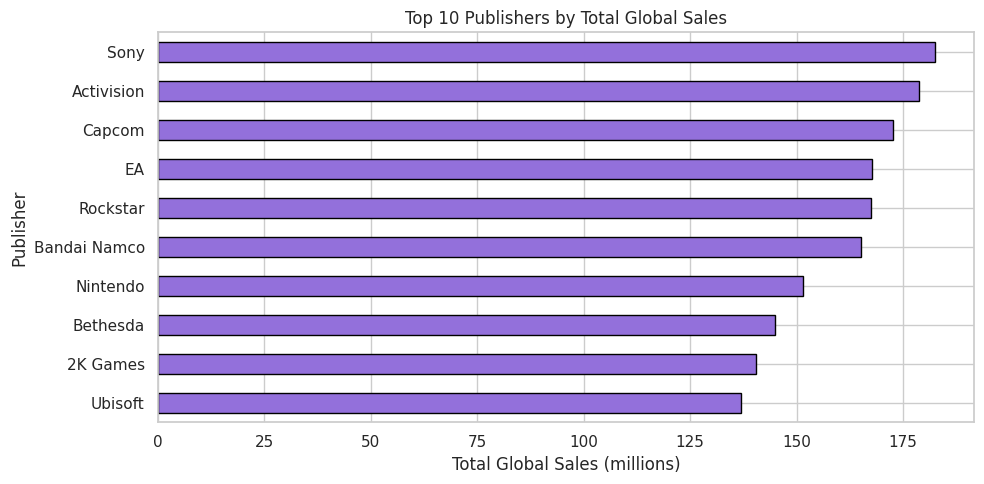

In [81]:
# Top 10 publishers by total global sales
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_publishers.plot(kind='barh', color='mediumpurple', edgecolor='black')
plt.title('Top 10 Publishers by Total Global Sales')
plt.xlabel('Total Global Sales (millions)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The top publishers analysis highlights which companies dominate the global gaming market in terms of total revenue. Publishers with large, well-known franchises (like Nintendo or EA) typically appear at the top of this list.

## Step 13: Outlier Detection

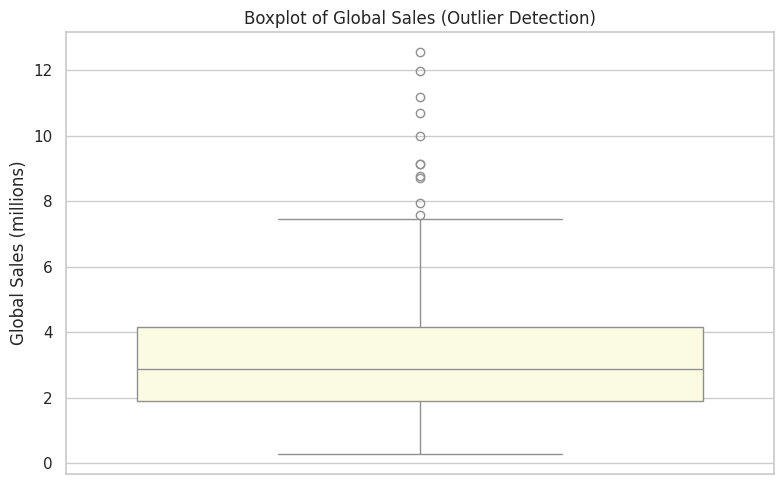

In [82]:
# Boxplot to detect outliers in Global Sales
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Global_Sales'], color='lightyellow')
plt.title('Boxplot of Global Sales (Outlier Detection)')
plt.ylabel('Global Sales (millions)')
plt.tight_layout()
plt.show()

The boxplot reveals the presence of outliers in global sales — games that significantly outperform the average. In machine learning, such outliers can skew model training and should be handled appropriately, either by capping values, applying log transformation, or using robust algorithms.

## Step 14: Sales Trend Over Time

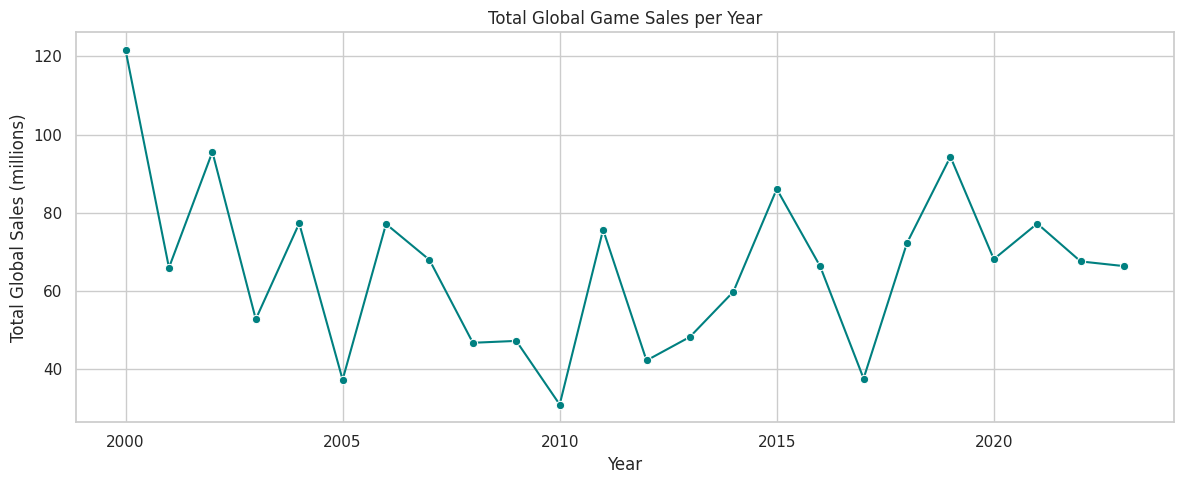

In [83]:
# Total global sales per year
yearly_sales = df.dropna(subset=['Year']).groupby('Year')['Global_Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_sales, x='Year', y='Global_Sales', marker='o', color='teal')
plt.title('Total Global Game Sales per Year')
plt.xlabel('Year')
plt.ylabel('Total Global Sales (millions)')
plt.tight_layout()
plt.show()

The sales trend over time helps identify growth and decline periods in the gaming industry. Peaks may correspond to popular console launches or hit titles, while dips may reflect market saturation or economic downturns. Time-based patterns are useful for forecasting future performance.

## Conclusion

In this lab, we performed a thorough Exploratory Data Analysis (EDA) on the **Video Game Sales** dataset. Here is a summary of what was done:

1. **Loaded the dataset** and inspected the first few rows to understand its structure.
2. **Checked and fixed data types** — ensuring numerical and date columns are in the right format.
3. **Identified missing values** — the `Year` column had some null entries.
4. **Confirmed no duplicate rows** exist in the dataset.
5. **Computed summary statistics** to understand the scale and spread of sales data.
6. **Explored categorical columns** — Platform, Genre, and Publisher distributions.
7. **Visualized distributions** — Global Sales is right-skewed, indicating a few blockbuster games.
8. **Analyzed correlations** — regional sales are strongly correlated with global sales.
9. **Identified outliers** using boxplots — some games have exceptionally high sales.
10. **Examined trends over time** — sales show variation across years.

EDA gave us a solid understanding of the data before moving to model building.
